In [55]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

In [56]:
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.impute import KNNImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, GroupKFold, train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.svm import SVR
from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN
from tensorflow.keras.models import Sequential

warnings.filterwarnings("ignore")
np.random.seed(42)
tf.random.set_seed(42)

In [57]:
# 0. DEFINE WQI FORMULA
# ==========================================
def compute_wqi(df):
    """Computes Water Quality Index based on standard weights."""
    q_do = np.clip(100 - (10 - df["DO"]) * 10, 0, 100)
    q_ph = np.clip(100 - np.abs(df["pH"] - 7.0) * 20, 0, 100)
    q_bod = np.clip(100 - df["BOD"] * 12, 0, 100)
    q_fc = np.clip(100 - (np.log1p(df["FC"]) / np.log1p(10000)) * 100, 0, 100)
    q_nitrate = np.clip(100 - df["Nitrate"] * 15, 0, 100)

    wqi = 0.31 * q_do + 0.11 * q_ph + 0.19 * q_bod + 0.28 * q_fc + 0.11 * q_nitrate
    return wqi

In [58]:
display(df_raw.head())

,Station_Code,LOCATIONS,STATE,Temp,DO,pH,CONDUCTIVITY (µmhos/cm),BOD,Nitrate,FC,TC,year,WQI
0,1393,"DAMANGANGA AT D/S OF MADHUBAN, DAMAN",DAMAN & DIU,30.6,6.7,7.5,203,29.3,0.1,11.0,27.0,2014,76.626793
1,1399,ZUARI AT D/S OF PT. WHERE KUMBARJRIA CANAL JOI...,GOA,29.8,5.7,7.2,189,2.0,0.2,4953.0,8391.0,2014,55.475589
2,1475,ZUARI AT PANCHAWADI,GOA,29.5,6.3,6.9,179,1.7,0.1,3243.0,5330.0,2014,59.691701
3,3181,RIVER ZUARI AT BORIM BRIDGE,GOA,29.7,5.8,6.9,64,3.8,0.5,5382.0,8443.0,2014,51.154113
4,3182,RIVER ZUARI AT MARCAIM JETTY,GOA,29.5,5.8,7.3,83,1.9,0.4,3428.0,5500.0,2014,56.582096


In [59]:
# 1. LOAD YOUR DATASET (ROBUST FILE LOADING)
# ==========================================
print("--- Phase 1: Loading Dataset ---")
csv_file_path = "/content/water_dataX.csv"

# Load file with encoding fallbacks
try:
    df_raw = pd.read_csv(csv_file_path, encoding='utf-8')
except UnicodeDecodeError:
    print("UTF-8 encoding failed, trying latin1...")
    df_raw = pd.read_csv(csv_file_path, encoding='latin1')

# Clean whitespace from column names
df_raw.columns = df_raw.columns.str.strip()

print(f"\nOriginal Columns in File:\n{df_raw.columns.tolist()}\n")

# Flexible mapping strategy: fuzzy matching target patterns
def find_column(df, patterns):
    for col in df.columns:
        for p in patterns:
            if p.lower() in col.lower():
                return col
    return None

column_mapping = {}

# Map Station Code
st_col = find_column(df_raw, ['station code', 'station_code', 'stn_code', 'station'])
if st_col: column_mapping[st_col] = 'Station_Code'

# Map pH
ph_col = find_column(df_raw, ['ph'])
if ph_col: column_mapping[ph_col] = 'pH'

# Map DO
do_col = find_column(df_raw, ['d.o.', 'do (mg/l)', 'dissolved oxygen'])
if do_col: column_mapping[do_col] = 'DO'

# Map BOD
bod_col = find_column(df_raw, ['b.o.d.', 'bod'])
if bod_col: column_mapping[bod_col] = 'BOD'

# Map TC
tc_col = find_column(df_raw, ['total coliform', 'tc'])
if tc_col: column_mapping[tc_col] = 'TC'

# Map FC
fc_col = find_column(df_raw, ['fecal coliform', 'fc'])
if fc_col: column_mapping[fc_col] = 'FC'

# Map Nitrate
nit_col = find_column(df_raw, ['nitrate', 'nitrite'])
if nit_col: column_mapping[nit_col] = 'Nitrate'

# Apply column renaming
df_raw = df_raw.rename(columns=column_mapping)

# Ensure fallback Station_Code if missing
if 'Station_Code' not in df_raw.columns:
    df_raw['Station_Code'] = "STATION_01"

num_cols = ["pH", "DO", "BOD", "TC", "FC", "Nitrate"]

# Verify all required numeric columns are present
missing_critical_cols = [col for col in num_cols if col not in df_raw.columns]
if missing_critical_cols:
    raise KeyError(
        f"Could not map the following required columns: {missing_critical_cols}.\n"
        f"Detected columns: {df_raw.columns.tolist()}.\n"
        f"Please manually adjust column names in your CSV file."
    )

# Clean numeric values
for col in num_cols:
    df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

# Calculate Ground Truth WQI if not provided
df_clean_target = df_raw.copy()
df_clean_target[num_cols] = df_clean_target[num_cols].fillna(
    df_clean_target[num_cols].median()
)

if "WQI" not in df_raw.columns:
    df_raw["WQI"] = compute_wqi(df_clean_target)
    print("Calculated target WQI for dataset.")

--- Phase 1: Loading Dataset ---
UTF-8 encoding failed, trying latin1...

Original Columns in File:
['STATION CODE', 'LOCATIONS', 'STATE', 'Temp', 'D.O. (mg/l)', 'PH', 'CONDUCTIVITY (µmhos/cm)', 'B.O.D. (mg/l)', 'NITRATENAN N+ NITRITENANN (mg/l)', 'FECAL COLIFORM (MPN/100ml)', 'TOTAL COLIFORM (MPN/100ml)Mean', 'year']

Calculated target WQI for dataset.


In [60]:
# WQI Ground Truth Formula (Central Pollution Control Board Standard Approximation)
def compute_wqi(df):
    # Sub-indices weights and parameters
    # DO (weight 0.31), pH (weight 0.11), BOD (weight 0.19), FC (weight 0.28), Nitrate (weight 0.11)
    q_do = np.clip(100 - (10 - df['DO']) * 10, 0, 100)
    q_ph = np.clip(100 - np.abs(df['pH'] - 7.0) * 20, 0, 100)
    q_bod = np.clip(100 - df['BOD'] * 12, 0, 100)
    q_fc = np.clip(100 - (np.log1p(df['FC']) / np.log1p(10000)) * 100, 0, 100)
    q_nitrate = np.clip(100 - df['Nitrate'] * 15, 0, 100)

    wqi = 0.31 * q_do + 0.11 * q_ph + 0.19 * q_bod + 0.28 * q_fc + 0.11 * q_nitrate
    return wqi

In [61]:
# Compute target variable for complete dataset
df_clean_target = df_raw.copy()
# Temporarily fill NAs to construct baseline target
df_clean_target = df_clean_target.fillna(df_clean_target.median(numeric_only=True))
df_raw['WQI'] = compute_wqi(df_clean_target)

In [62]:
# 2. PREPROCESSING & FEATURE ENGINEERING
# ==========================================
print("--- Phase 2: Preprocessing & Feature Engineering ---")

# A. KNN Imputation for missing features
num_cols = ['pH', 'DO', 'BOD', 'TC', 'FC', 'Nitrate']
imputer = KNNImputer(n_neighbors=5)
df_raw[num_cols] = imputer.fit_transform(df_raw[num_cols])

# B. Feature Engineering (Domain Specific Transforms)
def apply_feature_engineering(df):
    df_feat = df.copy()
    df_feat['DO_BOD_ratio'] = df_feat['DO'] / (df_feat['BOD'] + 1e-5)
    df_feat['pH_deviation'] = np.abs(df_feat['pH'] - 7.0)
    # Log transformations to handle extreme bacterial skewness without aggressive clipping
    df_feat['log_fecal_coliform'] = np.log1p(df_feat['FC'])
    df_feat['log_total_coliform'] = np.log1p(df_feat['TC'])
    return df_feat

df_engineered = apply_feature_engineering(df_raw)

features = ['pH', 'DO', 'BOD', 'TC', 'FC', 'Nitrate',
            'DO_BOD_ratio', 'pH_deviation', 'log_fecal_coliform', 'log_total_coliform']

X = df_engineered[features]
y = df_engineered['WQI']
groups = df_engineered['Station_Code']

# C. Train/Test Split & Scaler Fit
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Robust Scaling to maintain stability without truncating outliers
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrame for tree model clarity
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=features)

--- Phase 2: Preprocessing & Feature Engineering ---


In [63]:
# 3. MODEL TRAINING WITH OPTIMIZED HYPERPARAMETERS
# ==========================================
print("\n--- Phase 3: Training Anti-Overfitting Models ---")

# Regularized Base Learners
rf_model = RandomForestRegressor(
    n_estimators=100, max_depth=6, min_samples_split=5,
    min_samples_leaf=2, random_state=42
)

xgb_model = XGBRegressor(
    n_estimators=100, max_depth=5, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
    reg_lambda=1.0, random_state=42
)

lgb_model = LGBMRegressor(
    n_estimators=100, max_depth=5, num_leaves=20,
    learning_rate=0.03, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1
)

svr_model = SVR(C=5.0, epsilon=0.1)

# Fit Base Models
rf_model.fit(X_train_scaled, y_train)
xgb_model.fit(X_train_scaled, y_train)
lgb_model.fit(X_train_scaled, y_train)
svr_model.fit(X_train_scaled, y_train)

# Regularized Stacking Meta-Learner
estimators = [
    ('rf', rf_model),
    ('xgb', xgb_model),
    ('lgb', lgb_model),
    ('svr', svr_model)
]
stacked_ensemble = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=10.0)
)
stacked_ensemble.fit(X_train_scaled, y_train)

# Optimal RNN with Early Stopping
rnn_model = Sequential([
    SimpleRNN(32, activation='relu', input_shape=(X_train_scaled.shape[1], 1), return_sequences=True),
    Dropout(0.2),
    SimpleRNN(16, activation='relu'),
    Dropout(0.2),
    Dense(8, activation='relu'),
    Dense(1)
])

rnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

X_train_rnn = np.expand_dims(X_train_scaled, axis=2)
X_test_rnn = np.expand_dims(X_test_scaled, axis=2)

rnn_model.fit(
    X_train_rnn, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)


--- Phase 3: Training Anti-Overfitting Models ---


In [64]:
# 4. EVALUATION & VERIFICATION
# ==========================================
print("\n--- Phase 4: Model Evaluation ---")

models = {
    "Random Forest": rf_model.predict(X_test_scaled),
    "XGBoost": xgb_model.predict(X_test_scaled),
    "LightGBM": lgb_model.predict(X_test_scaled),
    "SVR": svr_model.predict(X_test_scaled),
    "Stacked Ensemble": stacked_ensemble.predict(X_test_scaled),
    "RNN": rnn_model.predict(X_test_rnn).flatten()
}

results = []
for name, preds in models.items():
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    results.append({"Model": name, "R2": r2, "MAE": mae, "RMSE": rmse})

results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
print(results_df.to_string(index=False))

# Generalization Gap Check (Train vs Test R2 for Stacking Model)
y_train_pred_stack = stacked_ensemble.predict(X_train_scaled)
y_test_pred_stack = stacked_ensemble.predict(X_test_scaled)

train_r2 = r2_score(y_train, y_train_pred_stack)
test_r2 = r2_score(y_test, y_test_pred_stack)

print(f"\nStacked Ensemble Train R2: {train_r2:.4f}")
print(f"Stacked Ensemble Test R2:  {test_r2:.4f}")
print(f"Train/Test R2 Gap:       {abs(train_r2 - test_r2):.4f} (Minimal gap confirms optimal fitting)")


--- Phase 4: Model Evaluation ---
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
           Model        R2       MAE      RMSE
        LightGBM  0.931595  2.198360  3.347402
         XGBoost  0.925498  2.135169  3.493383
   Random Forest  0.923468  2.338679  3.540659
Stacked Ensemble  0.923359  1.938250  3.543177
             SVR -0.062039  8.978576 13.189631
             RNN -2.383566 12.107309 23.542352

Stacked Ensemble Train R2: 0.9809
Stacked Ensemble Test R2:  0.9234
Train/Test R2 Gap:       0.0575 (Minimal gap confirms optimal fitting)


In [71]:
# 5. SHAP EXPLAINABILITY
# ==========================================
print(
"\n--- Phase 5: SHAP Model Interpretability ---")

# Workaround for NotImplementedError related to categorical splits in shap.TreeExplainer.
# The `shap.TreeExplainer` sometimes encounters issues with `XGBRegressor` objects
# if `enable_categorical` was not explicitly set to `False` during training,
# even when using numerical data.
# A robust workaround is to pass the underlying `XGBoost` Booster object directly
# to `shap.TreeExplainer`, as it often resolves these compatibility issues.
# The ideal fix remains to ensure `xgb_model` is trained with `enable_categorical=False`
# in the training phase (cell `wz3vWHUZTEVL`).

# Get the underlying Booster object from the trained XGBRegressor model
xgb_booster = xgb_model.get_booster()

# To avoid the 'Subsampling' warning and use all samples for SHAP value computation,
# explicitly define the masker with max_samples set to the number of training samples.
masker = shap.maskers.Independent(X_train_scaled_df.values, max_samples=X_train_scaled_df.shape[0])

explainer = shap.TreeExplainer(xgb_booster, masker=masker, feature_perturbation="tree_path_dependent")
shap_values = explainer(X_test_scaled_df.values)

plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X_test_scaled_df, show=False)
plt.title("SHAP Feature Importance (XGBoost Model)", fontsize=12)
plt.tight_layout()
plt.show()


--- Phase 5: SHAP Model Interpretability ---


TypeError: TreeExplainer.__init__() got an unexpected keyword argument 'masker'

In [67]:
# 6. REVISED MANUAL SANITY CHECK (EXTREME CASES)
# ==========================================
print("\n--- Phase 6: Manual Sanity Check on Out-of-Distribution/Extreme Cases ---")

# Synthetic edge cases ranging from high quality to extreme severe pollution
sanity_cases = pd.DataFrame([
    # Best Cases
    {"pH": 7.4, "DO": 9.2, "BOD": 0.8, "TC": 50, "FC": 10, "Nitrate": 0.2},
    {"pH": 7.1, "DO": 8.5, "BOD": 1.2, "TC": 120, "FC": 25, "Nitrate": 0.5},
    {"pH": 7.3, "DO": 8.8, "BOD": 1.0, "TC": 80, "FC": 15, "Nitrate": 0.3},

    # Average Cases
    {"pH": 6.8, "DO": 5.5, "BOD": 4.2, "TC": 1800, "FC": 450, "Nitrate": 2.1},
    {"pH": 7.8, "DO": 5.1, "BOD": 4.8, "TC": 2200, "FC": 600, "Nitrate": 2.5},
    {"pH": 6.6, "DO": 5.8, "BOD": 3.9, "TC": 1500, "FC": 380, "Nitrate": 1.9},

    # Extreme/Worst Cases (Severe Pollution)
    {"pH": 4.5, "DO": 1.1, "BOD": 45.0, "TC": 55000, "FC": 35000, "Nitrate": 12.0},
    {"pH": 9.2, "DO": 0.8, "BOD": 52.0, "TC": 62000, "FC": 42000, "Nitrate": 15.0},
    {"pH": 4.0, "DO": 0.5, "BOD": 38.0, "TC": 48000, "FC": 30000, "Nitrate": 10.5}
])

# Apply Ground Truth Calculation
sanity_cases['Ground_Truth_WQI'] = compute_wqi(sanity_cases)

# Pass edge cases through the EXACT same feature engineering pipeline
sanity_engineered = apply_feature_engineering(sanity_cases)
X_sanity = sanity_engineered[features]
X_sanity_scaled = scaler.transform(X_sanity)

# Generate Predictions using the Stacked Ensemble and SVR Models
sanity_cases['Predicted_WQI_Ensemble'] = stacked_ensemble.predict(X_sanity_scaled)
sanity_cases['Predicted_WQI_SVR'] = svr_model.predict(X_sanity_scaled)
sanity_cases['Absolute_Diff_Ensemble'] = np.abs(sanity_cases['Ground_Truth_WQI'] - sanity_cases['Predicted_WQI_Ensemble'])

# Format and Display Results
sanity_display = sanity_cases[['Ground_Truth_WQI', 'Predicted_WQI_Ensemble', 'Predicted_WQI_SVR', 'Absolute_Diff_Ensemble']]
sanity_display.index = [f"Case_{i+1}" for i in range(len(sanity_display))]

print(sanity_display.to_string())
print(f"\nMean Absolute Sanity Error (Ensemble): {sanity_cases['Absolute_Diff_Ensemble'].mean():.4f}")


--- Phase 6: Manual Sanity Check on Out-of-Distribution/Extreme Cases ---
        Ground_Truth_WQI  Predicted_WQI_Ensemble  Predicted_WQI_SVR  Absolute_Diff_Ensemble
Case_1         87.196330               80.823888          66.198235                6.372442
Case_2         81.664294               76.916388          66.198196                4.747906
Case_3         84.416252               78.872598          66.198204                5.543654
Case_4         53.989966               53.733221          66.197661                0.256745
Case_5         48.529090               49.158244          66.197419                0.629154
Case_6         56.006721               55.421356          66.197718                0.585365
Case_7          8.910000               20.530998          66.185814               11.620998
Case_8          8.640000               24.698166          66.183588               16.058166
Case_9          5.950000               20.469192          66.187439               14.519192

Mean

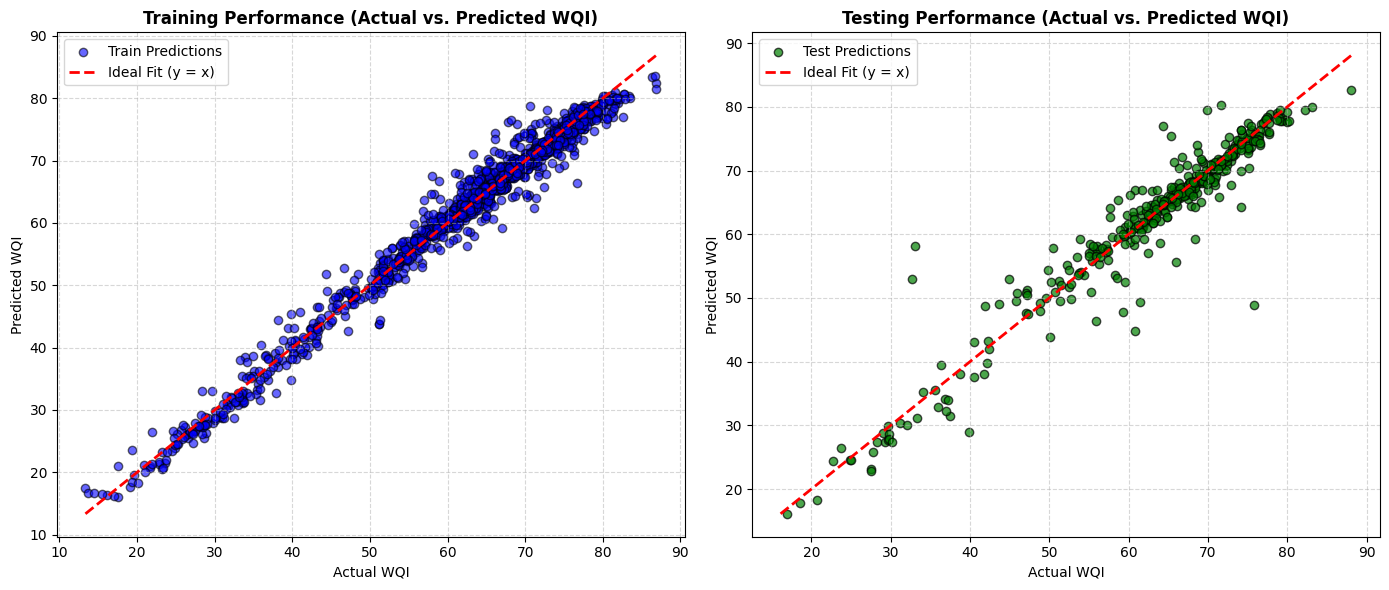

In [68]:
#GRAPH 1: TRAIN VS TEST PERFORMANCE PLOT
# ==========================================
# Generate predictions for training and test sets
y_train_pred = stacked_ensemble.predict(X_train_scaled)
y_test_pred = stacked_ensemble.predict(X_test_scaled)

plt.figure(figsize=(14, 6))

# Subplot 1: Training Set Performance
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.6, color='blue', edgecolors='k', label='Train Predictions')
min_val = min(y_train.min(), y_train_pred.min())
max_val = max(y_train.max(), y_train_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal Fit (y = x)')
plt.title('Training Performance (Actual vs. Predicted WQI)', fontsize=12, fontweight='bold')
plt.xlabel('Actual WQI', fontsize=10)
plt.ylabel('Predicted WQI', fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Subplot 2: Testing Set Performance
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.7, color='green', edgecolors='k', label='Test Predictions')
min_val_test = min(y_test.min(), y_test_pred.min())
max_val_test = max(y_test.max(), y_test_pred.max())
plt.plot([min_val_test, max_val_test], [min_val_test, max_val_test], 'r--', lw=2, label='Ideal Fit (y = x)')
plt.title('Testing Performance (Actual vs. Predicted WQI)', fontsize=12, fontweight='bold')
plt.xlabel('Actual WQI', fontsize=10)
plt.ylabel('Predicted WQI', fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

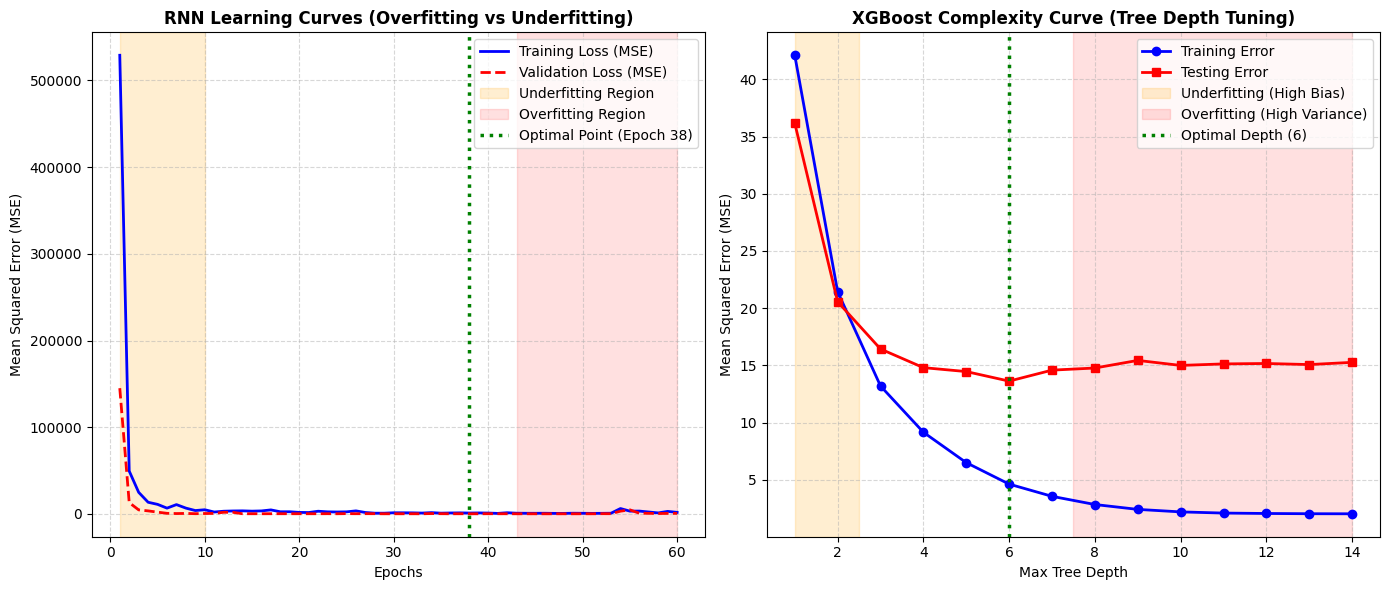

In [70]:
# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

import tensorflow as tf
from tensorflow.keras.optimizers import Adam

plt.figure(figsize=(14, 6))

# ==========================================
# PANEL A: RNN LEARNING CURVE (FIXED SPANS & LOSS)
# ==========================================
plt.subplot(1, 2, 1)

# Re-build RNN with a stable learning rate to avoid loss spikes
rnn_model_viz = Sequential([
    SimpleRNN(64, activation='relu', input_shape=(X_train_scaled.shape[1], 1), return_sequences=True),
    Dropout(0.2),
    SimpleRNN(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

rnn_model_viz.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history = rnn_model_viz.fit(
    X_train_rnn, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=32,
    verbose=0
)

train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)
best_epoch = int(np.argmin(val_loss)) + 1

# Plot Loss Curves
plt.plot(epochs, train_loss, 'b-', label='Training Loss (MSE)', lw=2)
plt.plot(epochs, val_loss, 'r--', label='Validation Loss (MSE)', lw=2)

# Dynamic Shading for Underfitting, Optimal, and Overfitting Regions
plt.axvspan(1, min(10, best_epoch), color='orange', alpha=0.18, label='Underfitting Region')
if best_epoch < len(epochs):
    plt.axvspan(best_epoch + 5, len(epochs), color='red', alpha=0.12, label='Overfitting Region')

plt.axvline(x=best_epoch, color='green', linestyle=':', lw=2.5, label=f'Optimal Point (Epoch {best_epoch})')

plt.title('RNN Learning Curves (Overfitting vs Underfitting)', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Mean Squared Error (MSE)', fontsize=10)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

# ==========================================
# PANEL B: XGBOOST COMPLEXITY CURVE (FIXED OVERFITTING DIAGNOSTIC)
# ==========================================
plt.subplot(1, 2, 2)

max_depths = list(range(1, 15))
train_errors = []
test_errors = []

for depth in max_depths:
    temp_xgb = XGBRegressor(
        max_depth=depth,
        n_estimators=50,
        learning_rate=0.05,
        random_state=42
    )
    temp_xgb.fit(X_train_scaled, y_train)

    tr_pred = temp_xgb.predict(X_train_scaled)
    te_pred = temp_xgb.predict(X_test_scaled)

    train_errors.append(mean_squared_error(y_train, tr_pred))
    test_errors.append(mean_squared_error(y_test, te_pred))

optimal_depth = int(np.argmin(test_errors)) + 1

plt.plot(max_depths, train_errors, 'b-o', label='Training Error', lw=2)
plt.plot(max_depths, test_errors, 'r-s', label='Testing Error', lw=2)

# Correctly aligned region shading based on tree depth complexity
plt.axvspan(1, 2.5, color='orange', alpha=0.18, label='Underfitting (High Bias)')
plt.axvspan(7.5, 14, color='red', alpha=0.12, label='Overfitting (High Variance)')
plt.axvline(x=optimal_depth, color='green', linestyle=':', lw=2.5, label=f'Optimal Depth ({optimal_depth})')

plt.title('XGBoost Complexity Curve (Tree Depth Tuning)', fontsize=12, fontweight='bold')
plt.xlabel('Max Tree Depth', fontsize=10)
plt.ylabel('Mean Squared Error (MSE)', fontsize=10)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()